## Titanic Dataset Cleaning

In [1]:
#import pandas
import pandas as pd 

In [2]:
#read the titanic dataset 
titanic =pd.read_csv('dataset/train.csv.csv')

In [3]:
#check the dimention of the dataset 
titanic.shape

(891, 12)

In [4]:
#check a sample  
titanic.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
547,548,1,2,"Padro y Manent, Mr. Julian",male,NaN,0,0,SC/PARIS 2146,13.8625,NaN,C
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5000,B77,S
828,829,1,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q
139,140,0,1,"Giglio, Mr. Victor",male,24.0,0,0,PC 17593,79.2000,B86,C


In [5]:
#check the overall info
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Identify the Problems and Solve them
(missing values,duplicated values,datatypes) 

## 1- Check the missing values 

In [6]:
#checking the missing value 
titanic.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
# checking the missing values in a more straightforward way
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

##  We have missing values in Age , Cabin , Embarked 
We will use fillna() function to fill the missing values. 
No need to drop any observations. 

## - Embarked 

In [8]:
#retreive the observation that has missing value 
embarked_missing = titanic[titanic['Embarked'].isna()]

In [9]:
#check the shape 
embarked_missing.shape

(2, 12)

In [10]:
#check few observations 
embarked_missing.sample(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN


- That shows that there IS SOME MISSING VALUES 

In [11]:
#fill missing values
titanic['Embarked']= titanic ['Embarked'].fillna('Q')

In [12]:
#test 
titanic['Embarked'].isnull().sum()

np.int64(0)

- NO missing values 

In [13]:
#showing a sample after filling the missing value 
titanic.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
860,861,0,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,NaN,S
450,451,0,2,"West, Mr. Edwy Arthur",male,36.0,1,2,C.A. 34651,27.7500,NaN,S
75,76,0,3,"Moen, Mr. Sigurd Hansen",male,25.0,0,0,348123,7.6500,F G73,S


## - Age 

In [14]:
# retrieve the observations that have missing values for age 
age_missing = titanic[titanic['Age'].isna()]

In [15]:
#check the shape
age_missing.shape

(177, 12)

In [16]:
# show a sample 
age_missing.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
740,741,1,1,"Hawksford, Mr. Walter James",male,NaN,0,0,16988,30.0000,D45,S
168,169,0,1,"Baumann, Mr. John D",male,NaN,0,0,PC 17318,25.9250,NaN,S
533,534,1,3,"Peter, Mrs. Catherine (Catherine Rizk)",female,NaN,0,2,2668,22.3583,NaN,C


- There IS SOME MISSING VALUES 

In [17]:
#fill missing values
titanic['Age']= titanic ['Age'].fillna('25')

In [18]:
#test 
titanic['Age'].isnull().sum()

np.int64(0)

- NO missing values 

In [19]:
#show a sample
titanic.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
150,151,0,2,"Bateman, Rev. Robert James",male,51.0,0,0,S.O.P. 1166,12.5250,NaN,S
140,141,0,3,"Boulos, Mrs. Joseph (Sultana)",female,25,0,2,2678,15.2458,NaN,C


## - Cabin 

In [20]:
# retrieve the observations that have missing values for Cabin
cabin_missing = titanic[titanic['Cabin'].isna()]

In [21]:
#check the shape
cabin_missing.shape

(687, 12)

In [22]:
# show a sample 
cabin_missing.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
836,837,0,3,"Pasic, Mr. Jakob",male,21.0,0,0,315097,8.6625,NaN,S
858,859,1,3,"Baclini, Mrs. Solomon (Latifa Qurban)",female,24.0,0,3,2666,19.2583,NaN,C
491,492,0,3,"Windelov, Mr. Einar",male,21.0,0,0,SOTON/OQ 3101317,7.2500,NaN,S


- There IS SOME MISSING VALUES 

In [23]:
#fill missing values
titanic['Cabin']= titanic ['Cabin'].fillna('A28')

In [24]:
#test 
titanic['Cabin'].isnull().sum()

np.int64(0)

- NO missing values 

In [25]:
# show a sample 
titanic.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
799,800,0,3,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.150,A28,S
719,720,0,3,"Johnson, Mr. Malkolm Joackim",male,33.0,0,0,347062,7.775,A28,S
766,767,0,1,"Brewe, Dr. Arthur Jackson",male,25,0,0,112379,39.600,A28,C


## 2- Check if there's any Duplicated Values 

In [26]:
#check the duplicated values
titanic.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [27]:
#check duplicated values in a more straightforward way
titanic.duplicated().sum()

np.int64(0)

- There is NO DUPLICATED VALUES 

## 3- Check The Data Types 

In [28]:
#check data types 
titanic.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age             object
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

- Transform Age from object into int64 

In [29]:
# Age transformation 
titanic ['Age']= titanic['Age'].astype('int64')

## Check the overall Info 

In [30]:
#check the overall info after cleaning the dataset
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 83.7+ KB


##  Non-graphical Techniques Exploration .

In [31]:
#show descriptive statistics 
titanic.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.749719,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.144366,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,25.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [32]:
# show the number of uunique values in Name
titanic['Name']. nunique ( )

891

In [33]:
# show the frequency table for Name 
titanic['Name'].value_counts()

Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

In [34]:
# show the number of unique values in PassengerID
titanic['PassengerId']. nunique ( )


891

In [35]:
# show the frequency table for PassengerId
titanic['PassengerId'].value_counts()

PassengerId
891    1
1      1
2      1
3      1
4      1
      ..
16     1
15     1
14     1
13     1
12     1
Name: count, Length: 891, dtype: int64

##  Graphical Techniques Exploration .

In [36]:
# import needed libraries 
import seaborn as sns
import matplotlib.pyplot as plt


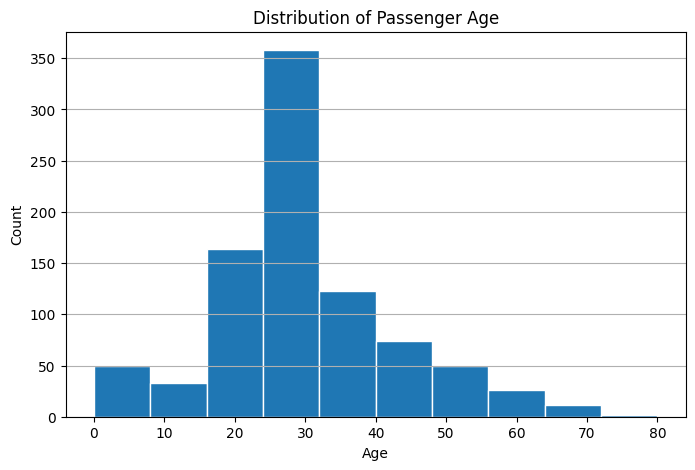

In [37]:
# histogram for Passenger Age
plt.figure(figsize=(8, 5))
plt.hist(titanic['Age'], edgecolor='white')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

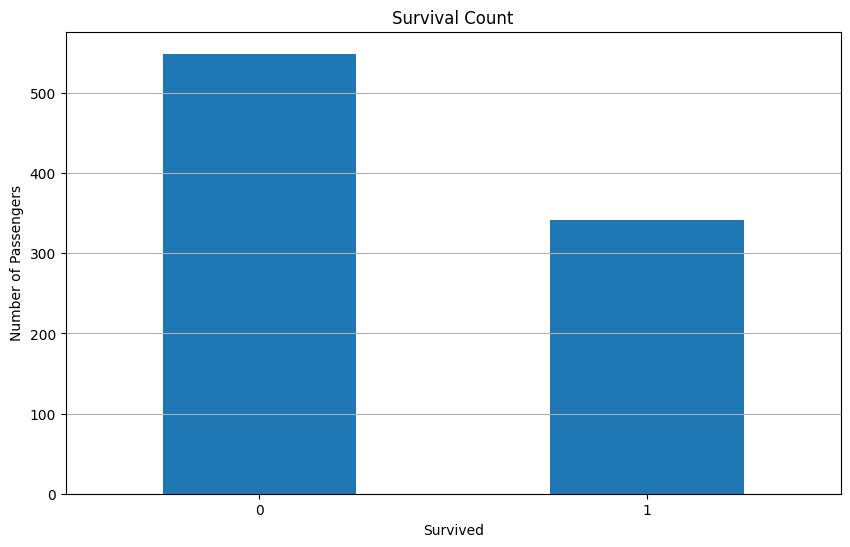

In [38]:
#bar plot for survival count 
plt.figure(figsize=(10,6))
titanic['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.grid(axis = 'y')
plt.show()

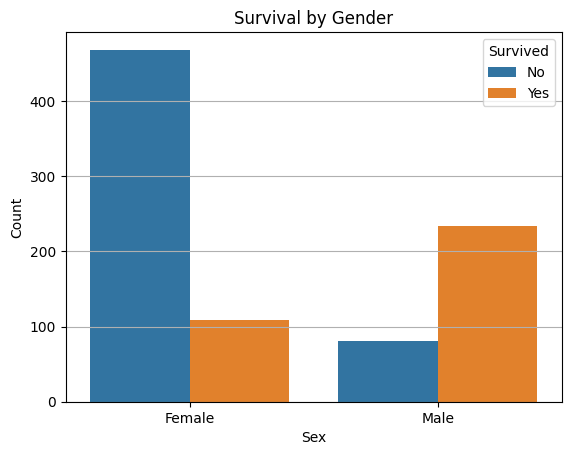

In [39]:
# bar plot for survival by gender 
sns.countplot(x='Sex', hue='Survived', data=titanic)
plt.title("Survival by Gender")
plt.xticks([0,1], ['Female', 'Male'])
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


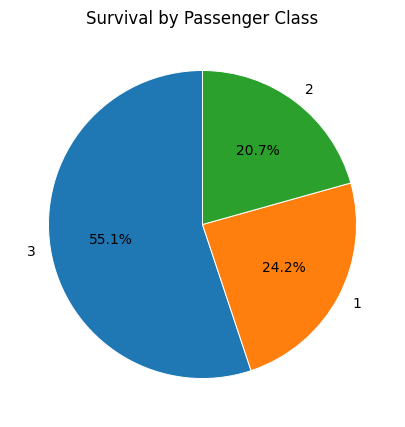

In [40]:
# pie chart for passenger class 
plt.figure(figsize=(10, 5))
labels = titanic['Pclass'].value_counts().index
plt.pie(titanic['Pclass'].value_counts(), labels=labels, autopct='%1.1f%%', wedgeprops={'edgecolor': 'white', 'linewidth': 0.7}, startangle=90)
plt.title('Survival by Passenger Class')
plt.show()